<a href="https://colab.research.google.com/github/youxiongching-web/demos/blob/main/Dupli_nbookFluorenc_6July_A04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
#nbroad_fluorescent_neuronal_cells
base_path = kagglehub.dataset_download('nbroad/fluorescent-neuronal-cells')

print('Data source import complete.')

Using Colab cache for faster access to the 'fluorescent-neuronal-cells' dataset.
Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
#
#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
  #  for filename in filenames:
      #  print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
#export PYTORCH_ALLOC_CONF=expandable_segments:True


print("done ✅ ")
# kagglehub.dataset_download('<owner>/<dataset-slug>')

done ✅ 


In [3]:
import os

# 1. 优先尝试系统自动生成的长变量名（如果它已经在之前的 Cell 中运行成功）
try:
    Base_path = base_path
#nbroad_fluorescent_neuronal_cells_path
    print("✅ 成功读取系统变量 'base_path  or nbroad_fluorescent_neuronal_cells_path'")
except NameError:
    # 2. 如果报 NameError，说明未定义，则自动切换为手动定义的标准路径
    print("⚠️ 系统长变量未检测到，正在自动启用手动定义路径...")

    # 结合您提供的真实路径，进行标准的平台绝对路径定义
   # Base_path = '/kaggle/input/datasets/nbroad/fluorescent-neuronal-cells'

# --- 🚀 核心：静默检查与变量定义（不打印冗长的文件列表） ---
images_dir = os.path.join(Base_path, 'all_images', 'images')
masks_dir = os.path.join(Base_path, 'all_masks', 'masks')

# 仅做最终的路径存在性确认
if os.path.exists(images_dir) and os.path.exists(masks_dir):
    print("✅ 路径配置完全正确！图片和掩膜目录已成功锁定。")
else:
    print("❌ 路径检查失败，请检查 '/kaggle/input/datasets/nbroad/...' 是否完整加载。")

✅ 成功读取系统变量 'base_path  or nbroad_fluorescent_neuronal_cells_path'
✅ 路径配置完全正确！图片和掩膜目录已成功锁定。


In [4]:
import os

# 1. 确保你的 base_path 已经成功指向了正确的输入路径
#base_path = '/kaggle/input/datasets/nbroad/fluorescent-neuronal-cells'

# 2. 用 base_path 反向定义/修复这个长变量
nbroad_fluorescent_neuronal_cells_path = base_path

# --- 🎯 静默验证（绝不刷屏） ---
if os.path.exists(nbroad_fluorescent_neuronal_cells_path):
    print("✅ 长变量 'nbroad_fluorescent_neuronal_cells_path' 已成功绑定并激活！")
else:
    print("❌ 警告：绑定的路径不存在，请检查 base_path 的字符串拼写是否正确。")

✅ 长变量 'nbroad_fluorescent_neuronal_cells_path' 已成功绑定并激活！


In [5]:
# 静默获取测试图和掩膜，绝不列印完整目录
if os.path.exists(images_dir):
    # 仅获取第一个文件的名字
    file_names = sorted(os.listdir(images_dir))
    if file_names:
        sample_img_name = file_names[0]  # 盲选第一张

        # 拼接出单张图片的完整路径
        sample_test_img_path = os.path.join(images_dir, sample_img_name)
        sample_test_mask_path = os.path.join(masks_dir, sample_img_name)

        print(f"\n🎯 已成功为您锁定测试目标，可直接用于模型测试：")
        print(f"原图路径: {sample_test_img_path}")
        print(f"掩膜路径: {sample_test_mask_path}")


🎯 已成功为您锁定测试目标，可直接用于模型测试：
原图路径: /kaggle/input/fluorescent-neuronal-cells/all_images/images/37_y.png
掩膜路径: /kaggle/input/fluorescent-neuronal-cells/all_masks/masks/37_y.png


In [6]:
#import os

# 1. 简单查看第一层目录
print("--- 第一层目录结构 ---")
#print(os.listdir(nbroad_fluorescent_neuronal_cells_path))

# 2. 递归查看前几层目录（避免文件太多刷屏）
print("\n--- 详细目录树状结构 ---")
for root, dirs, files in os.walk(nbroad_fluorescent_neuronal_cells_path):
    # 计算当前目录的深度，方便缩进
    level = root.replace(nbroad_fluorescent_neuronal_cells_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")

    # 只打印前几个文件作为示例，防止图片或文件太多导致输出过长
    subindent = ' ' * 4 * (level + 1)
    for f in files[:3]:
        print(f"{subindent}{f}")
    if len(files) > 3:
        print(f"{subindent}... 总共 {len(files)} 个文件")

--- 第一层目录结构 ---

--- 详细目录树状结构 ---
fluorescent-neuronal-cells/
    README.md
    all_images/
        LICENSE.txt
        images/
            MAR55S3C2R2_VLPAGR_20_o.png
            Mar26bS2C2R2_LHr_200x_y.png
            Mar23bS1C6R1_LHl_200x_y.png
            ... 总共 283 个文件
    all_masks/
        LICENSE.txt
        masks/
            MAR55S3C2R2_VLPAGR_20_o.png
            Mar26bS2C2R2_LHr_200x_y.png
            Mar23bS1C6R1_LHl_200x_y.png
            ... 总共 283 个文件


In [7]:
#import os
import glob
from sklearn.model_selection import train_test_split
from PIL import Image

# 1. 定义基础路径（记得结合你的长变量名）
base_path = nbroad_fluorescent_neuronal_cells_path
images_dir = os.path.join(base_path, 'all_images', 'images')
masks_dir = os.path.join(base_path, 'all_masks', 'masks')

# 2. 获取所有的图片和掩膜的完整路径，并排序确保它们一一对应
all_image_paths = sorted(glob.glob(os.path.join(images_dir, '*.png')))
all_mask_paths = sorted(glob.glob(os.path.join(masks_dir, '*.png')))

print(f"数据集中总共有 {len(all_image_paths)} 张图像和掩膜。")

# 3. 随机划分为 80% 训练集, 20% 测试集 (设置 random_state 保证每次运行结果一致)
train_imgs, test_imgs, train_masks, test_masks = train_test_split(
    all_image_paths, all_mask_paths, test_size=0.2, random_state=42
)

print(f"划分完成：训练集 {len(train_imgs)} 张，测试集 {len(test_imgs)} 张。")

# --- 🎯 选择并预览测试集中的第一张图 ---
sample_test_img_path = test_imgs[0]
sample_test_mask_path = test_masks[0]

print(f"\n为你挑选的测试图路径: {sample_test_img_path}")
print(f"对应的 Mask 标注路径: {sample_test_mask_path}")

# 预览选中的测试图和掩膜
img = Image.open(sample_test_img_path)
mask = Image.open(sample_test_mask_path)

print("\n[预览提示] 可以在 Jupyter 中直接查看选中的测试对：")
#display(img)
# 如果 mask 看起来是一片黑，是因为像素值可能是 0 和 1（需要乘以 255 放大对比度）
#display(mask)

数据集中总共有 283 张图像和掩膜。
划分完成：训练集 226 张，测试集 57 张。

为你挑选的测试图路径: /kaggle/input/fluorescent-neuronal-cells/all_images/images/MAR55S1C5R3_DMR_20_o.png
对应的 Mask 标注路径: /kaggle/input/fluorescent-neuronal-cells/all_masks/masks/MAR55S1C5R3_DMR_20_o.png

[预览提示] 可以在 Jupyter 中直接查看选中的测试对：


In [8]:
import torch
#import torch.nn
from torch import nn

from torch.utils.data import Dataset, DataLoader
import torchvision.transforms. functional as TF
import random
from PIL import Image
class CellDataset(Dataset):
    def __init__(self, image_paths, mask_paths, train=True, intensity_scale=1.0):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.train = train
        self.intensity_scale = intensity_scale          # 新增

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("L")
        mask = Image.open(self.mask_paths[idx]).convert("L")
        image = TF.resize(image, [512, 512])
        mask = TF.resize(mask, [512, 512], interpolation=TF.InterpolationMode.NEAREST)

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)

        image = image * self.intensity_scale            # 可调
        image = (image - image.mean()) / (image.std() + 1e-8)

        if self.train:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)
        return image, mask
    # 暂时注释掉自定义的 CombinedLoss
# criterion = CombinedLoss()

# 改用官方自带的损失函数
criterion = nn.BCEWithLogitsLoss()
print("ready ")

ready 


import os
os.environ["HF_TOKEN"] = "你的_HF_TOKEN_粘贴在这里"


In [9]:
!pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.3 MB/s eta 0:00:00


In [10]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.amp import GradScaler, autocast

# --- 1. 准备数据 ---
# 确保使用修正后的 CellDataset
train_dataset = CellDataset(train_imgs, train_masks, train=True)
test_dataset = CellDataset(test_imgs, test_masks, train=False)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# --- 2. 定义模型 (Unet++) ---
model = smp.UnetPlusPlus(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    #classes=1,
    #activation= "sigmoid"
)

# --- 3. 训练设置 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 组合损失函数
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss = nn.BCEWithLogitsLoss()

# 优化器和调度器
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

num_epochs = 15
scaler = GradScaler('cuda')

# --- 4. 训练循环 ---
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        optimizer.zero_grad()

        with autocast('cuda'):
            outputs = model(images)
            loss = dice_loss(outputs, masks) + bce_loss(outputs, masks)  # 组合损失

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss: {avg_loss:.4f}")
    scheduler.step(avg_loss)  # 更新学习率

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch [1/15], Avg Loss: 1.4816
Epoch [2/15], Avg Loss: 1.2520
Epoch [3/15], Avg Loss: 1.1744
Epoch [4/15], Avg Loss: 1.1325
Epoch [5/15], Avg Loss: 1.1045
Epoch [6/15], Avg Loss: 1.0741
Epoch [7/15], Avg Loss: 1.0518
Epoch [8/15], Avg Loss: 1.0285
Epoch [9/15], Avg Loss: 1.0087
Epoch [10/15], Avg Loss: 0.9839
Epoch [11/15], Avg Loss: 0.9643
Epoch [12/15], Avg Loss: 0.9402
Epoch [13/15], Avg Loss: 0.9207
Epoch [14/15], Avg Loss: 0.8958
Epoch [15/15], Avg Loss: 0.8740


🎯 模型在该视野内共检测到 42 个细胞个体。


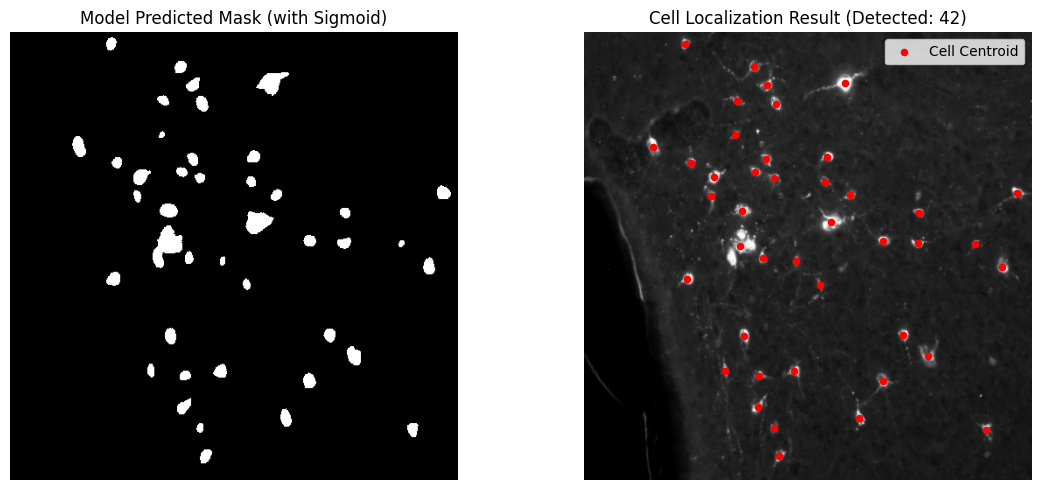

In [11]:
import torch
#from torch import nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import label, center_of_mass
import torchvision.transforms.functional as TF

# --- 1. 设置推理设备与切换评估模式 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# 从测试集中拿第一张做测试
sample_path = test_imgs[0]
raw_image = Image.open(sample_path).convert("L")

# --- 2. 严格保持与训练集完全一致的预处理流程 ---
intensity_scale = 1.0  # 需与 CellDataset 中的参数一致
input_tensor = TF.resize(raw_image, [512, 512])
input_tensor = TF.to_tensor(input_tensor)

# 💡 补全归一化操作
input_tensor = input_tensor * intensity_scale
input_tensor = (input_tensor - input_tensor.mean()) / (input_tensor.std() + 1e-8)
input_tensor = input_tensor.unsqueeze(0).to(device)  # [1, 1, 512, 512]

# --- 3. 模型前向推理预测 ---
with torch.no_grad():
    pred_logits = model(input_tensor)
    # 💡 必须施加 Sigmoid 将 Logits 转换为 0~1 的概率区间
    pred_prob = torch.sigmoid(pred_logits)
    pred_prob = pred_prob.squeeze().cpu().numpy()  # [512, 512]

# --- 4. 通过连通域提取细胞坐标 ---
# 此时 pred_prob 为概率值，可以安全地使用 0.5 ~ 0.7 作为阈值
binary_mask = (pred_prob > 0.7).astype(np.uint8)

labeled_mask, num_features = label(binary_mask)
centroids = center_of_mass(binary_mask, labeled_mask, range(1, num_features + 1))

print(f"🎯 模型在该视野内共检测到 {num_features} 个细胞个体。")

# --- 5. 可视化定位结果 ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(binary_mask, cmap='gray')
plt.title("Model Predicted Mask (with Sigmoid)")
plt.axis('off')

plt.subplot(1, 2, 2)
resized_img = TF.resize(raw_image, [512, 512])
plt.imshow(resized_img, cmap='gray')

if num_features > 0:
    xs = [c[1] for c in centroids]
    ys = [c[0] for c in centroids]
    plt.scatter(xs, ys, c='red', s=20, marker='o', label='Cell Centroid')
    plt.legend(loc='upper right')

plt.title(f"Cell Localization Result (Detected: {num_features})")
plt.axis('off')
plt.tight_layout()
plt.show()

from pathlib import Path

from torch.amp import autocast, GradScaler # Updated import based on F
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# 直接把 test_imgs[0] 赋值给 sample_path，不要加引号！
sample_path = test_imgs[0]

# 使用 Image.open 读取
raw_image = Image.open(sample_path)

# 使用 matplotlib 显示
plt.imshow(raw_image)
plt.axis('off')  # 关闭坐标轴显示
plt.show()


import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import label, center_of_mass
import torchvision.transforms.functional as TF

# --- 1. 设置推理设备与切换评估模式 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()  # 切换为测试/评估模式

# 从你之前分好的测试集 test_imgs 中拿第一张做测试
sample_path = test_imgs[0]
raw_image = Image.open(sample_path).convert("L")

# 保持与训练集完全一致的预处理流程
input_tensor = TF.resize(raw_image, [512, 512])
input_tensor = TF.to_tensor(input_tensor) * 0.7
input_tensor = input_tensor.unsqueeze(0).to(device)  # 增加 Batch 维度 [1, 1, 256, 256]

# --- 2. 模型前向推理预测 ---
with torch.no_grad():
    pred_mask = model(input_tensor)
    pred_mask = pred_mask.squeeze().cpu().numpy()  # 降维并转回 numpy 矩阵 [256, 256]

# --- 3. 核心：通过连通域提取细胞坐标 ---
# 设定阈值将模型输出概率（0~1）转化为二值图（0 或 1）
binary_mask = (pred_mask > 0.7).astype(np.uint8)

# 使用 scipy 自动标记连通区域（每个独立的细胞会被赋予不同的整数标签）
labeled_mask, num_features = label(binary_mask)

# 计算每个被标记细胞的质心（即细胞的中心点 Y, X 坐标）
# 注意：center_of_mass 返回的是 (row, col) 对应 (Y, X)
centroids = center_of_mass(binary_mask, labeled_mask, range(1, num_features + 1))

print(f"🎯 模型在该视野内共检测到 {num_features} 个细胞个体。")
print("部分细胞中心坐标示例 (X, Y):")
for i, (y, x) in enumerate(centroids[:5]):
    print(f" 细胞 #{i+1}: ({x:.1f}, {y:.1f})")

# --- 4. 可视化定位结果 ---
plt.figure(figsize=(12, 5))

# 左图：展示模型生成的掩膜
plt.subplot(1, 2, 1)
plt.imshow(binary_mask, cmap='gray')
plt.title("Model Predicted Mask")
plt.axis('off')

# 右图：在原始调整大小后的图像上绘制定位红点
plt.subplot(1, 2, 2)
# 将输入 Tensor 还原为可视化图像
resized_img = TF.resize(raw_image, [512, 512])
plt.imshow(resized_img, cmap='gray')

# 遍历坐标，使用 plt.scatter 打上定位红点
if num_features > 0:
    xs = [c[1] for c in centroids]
    ys = [c[0] for c in centroids]
    plt.scatter(xs, ys, c='red', s=20, marker='o', label='Cell Centroid')
    plt.legend(loc='upper right')

plt.title(f"Cell Localization Result (Detected: {num_features})")
plt.axis('off')
plt.tight_layout()
plt.show()


model.gradient_checkpointing_enable()


for images, masks in train_loader:
    images, masks = images.to(device), masks.to(device)
    

num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

import csv
import json
#import os